json형식 : 전세계 지진 데이터로 지도 만들기 

In [2]:
import csv

file_path = 'weather_data/sitka_weather_2021_simple.csv'

with open(file_path, 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    
    # 헤더 출력
    print('header:', reader.fieldnames)

    # 첫 줄만 타이틀: 값 형태로 출력
    for row in reader:
        result = [f"{key}: {value}" for key, value in row.items()]
        print(', '.join(result))
        break  # 한 줄만 출력하고 종료


header: ['STATION', 'NAME', 'DATE', 'TAVG', 'TMAX', 'TMIN']
STATION: USW00025333, NAME: SITKA AIRPORT, AK US, DATE: 2021-01-01, TAVG: , TMAX: 44, TMIN: 40


In [6]:
data = {
    "STATION": "USW00025333", 
    "NAME": "SITKA AIRPORT, AK US", 
    "DATE": "2021-01-01", 
    "TAVG": 70, 
    "TMAX": 44, 
    "TMIN": 40
}
type(data)

dict

In [ ]:
import json

file_path = 'weather.json'

with open(file_path, 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)

In [ ]:
eq_data_1_day_m1.geojson

In [9]:
import json

# 파일 경로
file_path = 'weather_data/eq_data_1_day_m1.geojson'

# JSON 파일 열기 및 첫 feature의 속성 타이틀 출력
with open(file_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

# 첫 feature의 속성 추출
first_feature = data['features'][0]
first_properties_keys = list(first_feature['properties'].keys())

first_properties_keys


['mag',
 'place',
 'time',
 'updated',
 'tz',
 'url',
 'detail',
 'felt',
 'cdi',
 'mmi',
 'alert',
 'status',
 'tsunami',
 'sig',
 'net',
 'code',
 'ids',
 'sources',
 'types',
 'nst',
 'dmin',
 'rms',
 'gap',
 'magType',
 'type',
 'title']

In [14]:
import json
import pandas as pd

# 파일 경로
file_path = 'weather_data/eq_data_1_day_m1.geojson'

# JSON 데이터 로드
with open(file_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

# 첫 번째 지진 정보 가져오기
first_feature = data['features'][0]
properties = first_feature['properties']

# 타이틀-값 쌍 출력 (DataFrame으로 보기 좋게)
df = pd.DataFrame(properties.items(), columns=["Title", "Value"])
print(df.head(20))  # 원하는 만큼 rows를 조절할 수 있음


      Title                                              Value
0       mag                                                1.6
1     place                       27 km NNW of Susitna, Alaska
2      time                                      1649051836769
3   updated                                      1649052020437
4        tz                                               None
5       url  https://earthquake.usgs.gov/earthquakes/eventp...
6    detail  https://earthquake.usgs.gov/earthquakes/feed/v...
7      felt                                               None
8       cdi                                               None
9       mmi                                               None
10    alert                                               None
11   status                                          automatic
12  tsunami                                                  0
13      sig                                                 39
14      net                                            

In [16]:
!pip install plotly


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 9.6/9.6 MB 60.8 MB/s eta 0:00:00

   ------------- -------------------------- 1/3 [narwhals]
   ------------- -------------------------- 1/3 [narwhals]
   ------------- -------------------------- 1/3 [narwhals]
   ------------- -------------------------- 1/3 [narwhals]
   ------------- -------------------------- 1/3 [narwhals]
   -------------------------- ------------- 2/3 [plotly]
   -------------------------- ------------- 2/3 [plotly]
   -------------------------- ------------- 2/3 [plotly]
   -------------------------- ------------- 2/3 [plotly]
   -------------------------- ------------- 2/3 [plotly]
   -------------------------- ------------- 2/3 [plotly]
   -------------------------- ------------- 2/3 [plotly]
   -------------------------- ------------- 2/3 [plotly]
   ---------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [22]:
import plotly.express as px
print("Plotly 설치 완료!")


Plotly 설치 완료!


In [20]:
import sys
!{sys.executable} -m pip install plotly


     ---------------------------------------- 9.6/9.6 MB 19.9 MB/s eta 0:00:00
     ------------------------------------- 373.4/373.4 KB 22.7 MB/s eta 0:00:00


You should consider upgrading via the 'c:\Users\user\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [24]:
pip install nbformat

     ---------------------------------------- 78.5/78.5 KB 4.5 MB/s eta 0:00:00
     ---------------------------------------- 88.7/88.7 KB ? eta 0:00:00
     ------------------------------------- 231.6/231.6 KB 14.8 MB/s eta 0:00:00
     ---------------------------------------- 63.8/63.8 KB ? eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\user\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [29]:
fig.write_html("earthquakes_map.html")

In [34]:
from pathlib import Path
import json

import plotly.express as px


# Read data as a string and convert to a Python object.
path = Path('eq_data/eq_data_30_day_m1.geojson')
contents = path.read_text(encoding='utf-8')
all_eq_data = json.loads(contents)

# Examine all earthquakes in the dataset.
all_eq_dicts = all_eq_data['features']

mags, lons, lats, eq_titles = [], [], [], []
for eq_dict in all_eq_dicts:
    mag = eq_dict['properties']['mag']
    lon = eq_dict['geometry']['coordinates'][0]
    lat = eq_dict['geometry']['coordinates'][1]
    eq_title = eq_dict['properties']['title']
    mags.append(mag)
    lons.append(lon)
    lats.append(lat)
    eq_titles.append(eq_title)

title = 'Global Earthquakes'
fig = px.scatter_geo(lat=lats, lon=lons, size=mags, title=title,
        color=mags,
        color_continuous_scale='Viridis',
        labels={'color':'Magnitude'},
        projection='natural earth',
        hover_name=eq_titles,
    )
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [30]:
fig.write_html("earthquakes_map.html")

In [ ]:
import os

print(os.path.abspath("earthquakes_map.html"))
print("Exists:", os.path.exists("earthquakes_map.html"))
#Exists: True라면 파일은 만들어졌습니다.
#경로가 맞다면 해당 경로에서 직접 열 수도 있습니다.

e:\work_python\pcc_3e-main\Task04\earthquakes_map.html
Exists: True


In [ ]:
import webbrowser

webbrowser.open("earthquakes_map.html")
#이 명령어를 실행하면 기본 브라우저로 바로 열립니다.

True

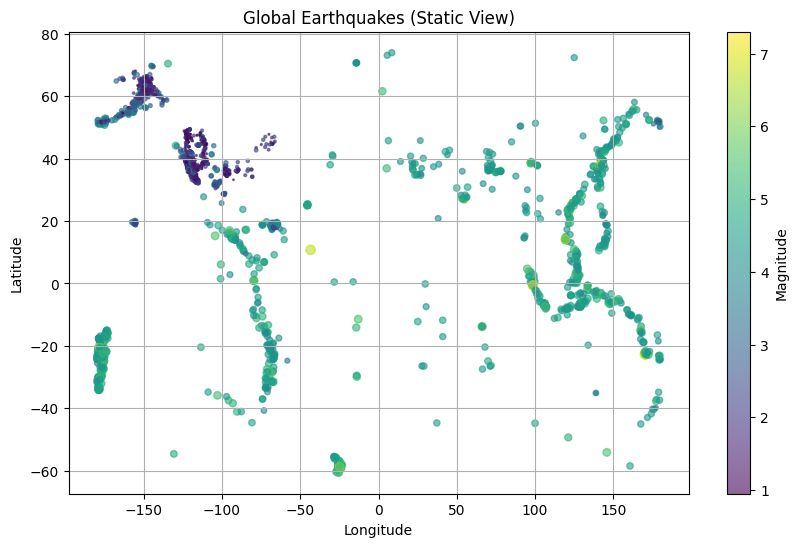

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(lons, lats, c=mags, cmap='viridis', s=[m**2 for m in mags], alpha=0.6)
plt.colorbar(label='Magnitude')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Global Earthquakes (Static View)')
plt.grid(True)
plt.show()


In [36]:
pip install --upgrade nbformat

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\user\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [43]:
import plotly.io as pio
pio.renderers.default = 'notebook_connected'  # 또는 'inline'

fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [42]:
!pip uninstall nbformat -y
!pip install nbformat
!pip install ipython

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 9.5/9.5 MB 50.7 MB/s eta 0:00:00

   ----------------------------------------  0/11 [pywin32]
   ----------------------------------------  0/11 [pywin32]
   ----------------------------------------  0/11 [pywin32]
   ----------------------------------------  0/11 [pywin32]
   ----------------------------------------  0/11 [pywin32]
   ----------------------------------------  0/11 [pywin32]
   ----------------------------------------  0/11 [pywin32]
   ----------------------------------------  0/11 [pywin32]
   ----------------------------------------  0/11 [pywin32]
   ----------------------------------------  0/11 [pywin32]
   ----------------------------------------  0/11 [pywin32]
   ------- --------------------------------  2/11 [traitlets]
   --------------------- ------------------  6/11 [re

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/611.0 kB ? eta -:--:--
   --------------------------------------- 611.0/611.0 kB 14.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 18.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 1.2/1.2 MB 36.6 MB/s eta 0:00:00

   ----------------------------------------  0/14 [wcwidth]
   ----- ----------------------------------  2/14 [pygments]
   ----- ----------------------------------  2/14 [pygments]
   ----- ----------------------------------  2/14 [pygments]
   ----- ----------------------------------  2/14 [pygments]
   ----- ----------------------------------  2/14 [pygments]
   ----- ----------------------------------  2/14 [pygments]
   ----- ----------------------------------  2/14 [p

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [44]:
from pathlib import Path
import json
import plotly.express as px
import plotly.io as pio

# ✅ Jupyter notebook에서 Plotly 그래프 표시용 설정
pio.renderers.default = 'notebook_connected'

# 데이터 파일 경로
path = Path("eq_data/eq_data_30_day_m1.geojson")  # 업로드한 파일명과 동일하게
contents = path.read_text(encoding='utf-8')
all_eq_data = json.loads(contents)

# 데이터 파싱
all_eq_dicts = all_eq_data["features"]

mags, lons, lats, eq_titles = [], [], [], []
for eq_dict in all_eq_dicts:
    mags.append(eq_dict['properties']['mag'])
    lons.append(eq_dict['geometry']['coordinates'][0])
    lats.append(eq_dict['geometry']['coordinates'][1])
    eq_titles.append(eq_dict['properties']['title'])

# 시각화
fig = px.scatter_geo(lat=lats, lon=lons, size=mags, title="Global Earthquakes",
                     color=mags,
                     color_continuous_scale='Viridis',
                     labels={'color': 'Magnitude'},
                     projection='natural earth',
                     hover_name=eq_titles)
fig.show()


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [52]:
import plotly.io as pio
pio.renderers.default = 'notebook_connected'  # 또는 'iframe', 'browser'
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [46]:
import nbformat
print(nbformat.__version__)

5.10.4


In [49]:
import plotly.io as pio
print(pio.renderers)



Renderers configuration
-----------------------
    Default renderer: 'iframe'
    Available renderers:
        ['plotly_mimetype', 'jupyterlab', 'nteract', 'vscode',
         'notebook', 'notebook_connected', 'kaggle', 'azure', 'colab',
         'cocalc', 'databricks', 'json', 'png', 'jpeg', 'jpg', 'svg',
         'pdf', 'browser', 'firefox', 'chrome', 'chromium', 'iframe',
         'iframe_connected', 'sphinx_gallery', 'sphinx_gallery_png']



In [51]:
!pip install --upgrade ipython ipykernel jupyterlab notebook


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ---------------------------- ----------- 8.7/12.3 MB 40.7 MB/s eta 0:00:01
   ---------------------------------------- 12.3/12.3 MB 42.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/14.3 MB ? eta -:--:--
   ---------------------------------------- 14.3/14.3 MB 73.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/10.2 MB ? eta -:--:--
   --------------------------------- ------ 8.7/10.2 MB 41.3 MB/s eta 0:00:01
   ---------------------------------------- 10.2/10.2 MB 34.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/5.3 MB ? eta -:--:--
   ---------------------------------------- 5.3/5.3 MB 26.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 27.6 MB/s eta 0:00:00
   ------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress t